In [1]:
import numpy as np
from matplotlib import pyplot as plt
from skimage import data, img_as_float
from skimage import color, exposure
from skimage.restoration import unwrap_phase

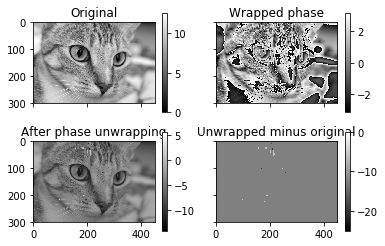

In [2]:
# Load an image as a floating-point grayscale
image = color.rgb2gray(img_as_float(data.chelsea()))

# Scale the image to [0, 4*pi]
image = exposure.rescale_intensity(image, 
                                   out_range=(0, 4 * np.pi))

# Create a phase-wrapped image in the interval [-pi, pi)
image_wrapped = np.angle(np.exp(1j * image))

# Perform phase unwrapping
image_unwrapped = unwrap_phase(image_wrapped)


fig, ax = plt.subplots(2, 2, sharex=True, 
                       sharey=True)
ax1, ax2, ax3, ax4 = ax.ravel()

fig.colorbar(ax1.imshow(image, cmap='gray', vmin=0, 
                        vmax=4 * np.pi), ax=ax1)
ax1.set_title('Original')

fig.colorbar(ax2.imshow(image_wrapped, cmap='gray', 
                        vmin=-np.pi, vmax=np.pi),
             ax=ax2)
ax2.set_title('Wrapped phase')

fig.colorbar(ax3.imshow(image_unwrapped, cmap='gray'), 
             ax=ax3)
ax3.set_title('After phase unwrapping')

fig.colorbar(ax4.imshow(image_unwrapped - image, 
                        cmap='gray'), ax=ax4)
ax4.set_title('Unwrapped minus original')
plt.show()